# XGBoost based Building Operation Data Classification

#### 0. Setting
#### 1. Extract time-series feature
#### 2. Name based automated labeler
#### 3. XGBoost Training (Multi-label)
#### 4. predict entire variable + selct single-label
#### 5. Main pipeline (generate predict CSV)
#### 6. Model Evaluate

# 0. Setting

In [47]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    hamming_loss,
)
from xgboost import XGBClassifier

In [48]:
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

TS_FILE = os.path.join(
    BASE_DIR,
    "Dataset",
    "Building_AllPoints_15m_2025Jan01_2025Oct01_COV_and_15min.csv"
)

OUTPUT_CSV_FILE = os.path.join(BASE_DIR, "AutoTag_XGBoost_Results.csv")
TIME_COL = "Timestamp"

# 1. Extract time-series feature

In [49]:
def extract_features_from_timeseries(ts_df: pd.DataFrame) -> pd.DataFrame:
    """Extract statistics/behavior/cycle by variable in 15 minute timeseries"""
    print("\n[1/4] Start extracting time-series feature...")

    if TIME_COL in ts_df.columns:
        ts_df[TIME_COL] = pd.to_datetime(ts_df[TIME_COL])
        ts_df = ts_df.set_index(TIME_COL)

    ts_df = ts_df.apply(pd.to_numeric, errors="coerce")

    feature_rows = []

    for col in ts_df.columns:
        series = ts_df[col].dropna()
        if series.empty:
            continue

        s = series.astype(float)

        mean_val = s.mean()
        std_val = s.std()
        min_val = s.min()
        max_val = s.max()
        rng_val = max_val - min_val

        zero_ratio = (s == 0).mean()
        nan_ratio = s.isna().mean()

        unique_vals = s.dropna().unique()
        is_binary = int(set(unique_vals).issubset({0, 1}))
        on_ratio = float((s == 1).mean()) if is_binary else np.nan

        s_diff = s.diff().fillna(0)
        switch_count = int((s_diff != 0).sum()) if is_binary else 0

        daily_lag = 96          # 24h
        weekly_lag = 96 * 7

        def autocorr_at_lag(x, lag):
            if len(x) <= lag:
                return np.nan
            x1 = x[:-lag]
            x2 = x[lag:]
            if x1.std() == 0 or x2.std() == 0:
                return np.nan
            return float(np.corrcoef(x1, x2)[0, 1])

        daily_ac = autocorr_at_lag(s.values, daily_lag)
        weekly_ac = autocorr_at_lag(s.values, weekly_lag)

        feature_rows.append({
            "CSV_Variable": col,
            "mean": mean_val,
            "std": std_val,
            "min": min_val,
            "max": max_val,
            "range": rng_val,
            "zero_ratio": zero_ratio,
            "nan_ratio": nan_ratio,
            "is_binary": is_binary,
            "on_ratio": on_ratio,
            "switch_count": switch_count,
            "daily_autocorr": daily_ac,
            "weekly_autocorr": weekly_ac,
        })

    feature_df = pd.DataFrame(feature_rows)
    print(f"  -> Comeplete extracting feaure: Variables {len(feature_df)}개")
    return feature_df

# 2. Name based automated labeler

In [50]:
def auto_label_from_name(var_name: str) -> dict:
    name = var_name.lower()

    tag_temperature = 0
    tag_flow = 0
    tag_pressure = 0
    tag_status = 0
    tag_command = 0
    tag_mode = 0

    if ("tmp" in name) or ("temp" in name):
        tag_temperature = 1

    if ("fl" in name) or ("flow" in name):
        tag_flow = 1

    if ("dp" in name) or ("press" in name) or ("prs" in name):
        tag_pressure = 1

    if ("sts" in name) or ("status" in name) or ("onoff" in name) \
       or ("_sts" in name) or name.endswith("sts"):
        tag_status = 1

    if ("cmd" in name) or ("command" in name) or name.endswith("cmd"):
        tag_command = 1

    if ("md" in name) or ("mode" in name) or ("econ" in name) \
       or ("occ" in name and "sts" not in name):
        tag_mode = 1

    return {
        "tag_temperature": tag_temperature,
        "tag_flow": tag_flow,
        "tag_pressure": tag_pressure,
        "tag_status": tag_status,
        "tag_command": tag_command,
        "tag_mode": tag_mode,
    }


def generate_auto_labels(feature_df: pd.DataFrame):
    print("\n[2/4] Generate variable name-based automated label...")

    label_rows = []
    for var in feature_df["CSV_Variable"]:
        labels = auto_label_from_name(var)
        labels["CSV_Variable"] = var
        label_rows.append(labels)

    label_df = pd.DataFrame(label_rows)

    merged = pd.merge(feature_df, label_df, on="CSV_Variable", how="left")

    tag_cols = [
        "tag_temperature",
        "tag_flow",
        "tag_pressure",
        "tag_status",
        "tag_command",
        "tag_mode",
    ]

    print(f"  -> Complete generating automated label: Vairables {len(merged)}개")
    print(f"  -> tag column: {tag_cols}")
    return merged, tag_cols

# 3. XGBoost Training (Multi-label)

In [51]:
def train_xgboost_models(merged_labeled: pd.DataFrame,
                         tag_cols: list[str]):
    print("\n[3/4] Start XGBoost model training...")

    feature_cols = [
        "mean", "std", "min", "max", "range",
        "zero_ratio", "nan_ratio", "is_binary",
        "on_ratio", "switch_count",
        "daily_autocorr", "weekly_autocorr"
    ]

    X = merged_labeled[feature_cols].fillna(0.0).values
    y_tag = merged_labeled[tag_cols].fillna(0).astype(int).values

    if y_tag.shape[0] < 4:
        print("! Too low number of sample")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_tag, test_size=0.3, random_state=42
    )

    models_tag = {}
    valid_tag_indices = []

    for i, tag in enumerate(tag_cols):
        y_train_i = y_train[:, i]
        unique_classes = np.unique(y_train_i)

        if unique_classes.shape[0] < 2:
            print(f"  -> Only one tag exist '{tag}' > Not process XGBoost training.")
            models_tag[tag] = None
            continue

        print(f"  -> Training XGBoost for tage '{tag}'...")
        clf = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1
        )
        clf.fit(X_train, y_train_i)
        models_tag[tag] = clf
        valid_tag_indices.append(i)

        if len(X_test) > 0:
            y_test_i = y_test[:, i]
            y_pred_tag = clf.predict(X_test)
            f1 = f1_score(y_test_i, y_pred_tag, zero_division=0)
            print(f"     '{tag}' F1-score: {f1:.3f}")

    if len(valid_tag_indices) > 0 and len(X_test) > 0:
        y_pred_all = np.zeros_like(y_test)
        for i, tag in enumerate(tag_cols):
            if models_tag[tag] is None:
                y_pred_all[:, i] = y_test[:, i]
            else:
                y_pred_all[:, i] = models_tag[tag].predict(X_test)

        micro_prec = precision_score(y_test, y_pred_all, average="micro", zero_division=0)
        micro_rec = recall_score(y_test, y_pred_all, average="micro", zero_division=0)
        micro_f1 = f1_score(y_test, y_pred_all, average="micro", zero_division=0)

        macro_prec = precision_score(y_test, y_pred_all, average="macro", zero_division=0)
        macro_rec = recall_score(y_test, y_pred_all, average="macro", zero_division=0)
        macro_f1 = f1_score(y_test, y_pred_all, average="macro", zero_division=0)

        hloss = hamming_loss(y_test, y_pred_all)

        print("\n* Summary Multi-label Performance (vs rule label):")
        print(f"  - Micro Precision: {micro_prec:.3f}, Micro Recall: {micro_rec:.3f}, Micro F1: {micro_f1:.3f}")
        print(f"  - Macro Precision: {macro_prec:.3f}, Macro Recall: {macro_rec:.3f}, Macro F1: {macro_f1:.3f}")
        print(f"  - Hamming Loss: {hloss:.3f}")
    else:
        print("\n  -> There are no meaningful tage -> do not process calcuating performance metric of multi-label")

    return models_tag, feature_cols


# 4. predict entire variable + selct single-label

In [52]:
def predict_for_all_variables(merged_labeled: pd.DataFrame,
                              models_tag: dict,
                              feature_cols: list[str],
                              tag_cols: list[str]) -> pd.DataFrame:
    print("\n[4/4] Perform predicting about entire variables...")

    X_all = merged_labeled[feature_cols].fillna(0.0).values
    result = merged_labeled[["CSV_Variable"] + tag_cols].copy()

    for tag in tag_cols:
        model = models_tag.get(tag, None)
        if model is None:
            result[f"{tag}_pred"] = result[tag]
            result[f"{tag}_prob"] = np.nan
            print(f"  -> Only use rule-based label for tag '{tag}' (XGBoost Not trained)")
        else:
            prob = model.predict_proba(X_all)[:, 1]
            pred = (prob >= 0.5).astype(int)
            result[f"{tag}_pred"] = pred
            result[f"{tag}_prob"] = prob

    return result


def choose_best_single_tag(row, tag_cols, prob_threshold=0.5):
    candidates = []
    for tag in tag_cols:
        pred = row.get(f"{tag}_pred", 0)
        prob = row.get(f"{tag}_prob", np.nan)
        prob_val = float(prob) if pd.notna(prob) else 0.0
        candidates.append((tag, pred, prob_val))

    ones = [c for c in candidates if c[1] == 1]

    if len(ones) == 1:
        chosen = ones[0]
    elif len(ones) > 1:
        chosen = max(ones, key=lambda x: x[2])
    else:
        chosen = max(candidates, key=lambda x: x[2])

    chosen_tag, _, chosen_prob = chosen
    label = chosen_tag.replace("tag_", "")

    if chosen_prob < prob_threshold:
        return "none", chosen_prob
    else:
        return label, chosen_prob

# 5. Main pipeline (generate predict CSV)

In [53]:
def run_autotag_xgboost():
    print("* Start pipeline: Time-series sensor automated XGBoost tagging *")

    if not os.path.exists(TS_FILE):
        print(f"! Error: can not find time-series file: {TS_FILE}")
        return

    print(f"\n[0/4] load time-series data: {TS_FILE}")
    ts_df = pd.read_csv(TS_FILE)

    # 1) Extract fearue
    feature_df = extract_features_from_timeseries(ts_df)

    # 2) Generate name based pseudo label
    merged_labeled, tag_cols = generate_auto_labels(feature_df)

    # 3) XGBoost training
    models_tag, feature_cols = train_xgboost_models(
        merged_labeled, tag_cols
    )

    # 4) Predict entire variable (Multi-label)
    prediction_df = predict_for_all_variables(
        merged_labeled, models_tag, feature_cols, tag_cols
    )

    # Add System_ID / Measurement_Type
    extra_rows = []
    for var in prediction_df["CSV_Variable"]:
        parts = var.split("_")
        system_id = parts[1] if len(parts) > 1 and parts[0].lower() == "regular" else "Other"
        measurement = parts[-1] if len(parts) > 0 else "N/A"
        extra_rows.append({
            "CSV_Variable": var,
            "System_ID": system_id,
            "Measurement_Type": measurement,
        })
    extra_df = pd.DataFrame(extra_rows)
    mapping_df = pd.merge(prediction_df, extra_df, on="CSV_Variable", how="left")

    ###############################
    # single-label select
    best_tags = mapping_df.apply(
        lambda row: choose_best_single_tag(row, tag_cols, prob_threshold=0.5),
        axis=1
    )
    best_tag_labels = [bt[0] for bt in best_tags]
    best_tag_probs = [bt[1] for bt in best_tags]

    mapping_df["Predicted_Tag"] = best_tag_labels
    mapping_df["Predicted_Tag_Prob"] = best_tag_probs

    # Slime version
    slim_df = mapping_df[[
        "CSV_Variable",
        "System_ID",
        "Measurement_Type",
        "Predicted_Tag",
        "Predicted_Tag_Prob",
    ]].copy()

    ######################################################
    # Golden_Tag process logic
    #   - file X: generate Golden_Tag empty column
    #   - file O: conservate last CSV with merging Golden_Tag

    if os.path.exists(OUTPUT_CSV_FILE):
        try:
            old_df = pd.read_csv(OUTPUT_CSV_FILE)
            if "Golden_Tag" in old_df.columns:
                slim_df = slim_df.merge(
                    old_df[["CSV_Variable", "Golden_Tag"]],
                    on="CSV_Variable",
                    how="left"
                )
            else:
                slim_df["Golden_Tag"] = ""
        except Exception as e:
            print(f"\n! Error-reading last result file, make new Golden_Tag: {e}")
            slim_df["Golden_Tag"] = ""
    else:
        # First run: generate empty Golden_Tag column
        slim_df["Golden_Tag"] = ""

    # Save CSV
    try:
        slim_df.to_csv(OUTPUT_CSV_FILE, index=False, encoding="utf-8")
        print(f"\n:) Saved as '{OUTPUT_CSV_FILE}'")
        print("   → Golden_Tag you can add temperature / flow / pressure / status / command / mode / none etc in column")
    except Exception as e:
        print(f"\n! Error saving CSV: {e}")
        return

    print("\n===== Example line =====")
    print(slim_df.head(5).to_string(index=False))

    return slim_df



if __name__ == "__main__":
    run_autotag_xgboost()


* Start pipeline: Time-series sensor automated XGBoost tagging *

[0/4] load time-series data: /Users/kim-yujin/Desktop/CSC_Mapping/Dataset/Building_AllPoints_15m_2025Jan01_2025Oct01_COV_and_15min.csv

[1/4] Start extracting time-series feature...
  -> Comeplete extracting feaure: Variables 15개

[2/4] Generate variable name-based automated label...
  -> Complete generating automated label: Vairables 15개
  -> tag column: ['tag_temperature', 'tag_flow', 'tag_pressure', 'tag_status', 'tag_command', 'tag_mode']

[3/4] Start XGBoost model training...
  -> Training XGBoost for tage 'tag_temperature'...
     'tag_temperature' F1-score: 0.500
  -> Only one tag exist 'tag_flow' > Not process XGBoost training.
  -> Only one tag exist 'tag_pressure' > Not process XGBoost training.
  -> Training XGBoost for tage 'tag_status'...
     'tag_status' F1-score: 1.000
  -> Only one tag exist 'tag_command' > Not process XGBoost training.
  -> Only one tag exist 'tag_mode' > Not process XGBoost training.



# 6. Model Evaluate


* evaluate Golden label based performance:
              precision    recall  f1-score   support

        flow       0.00      0.00      0.00         2
        none       0.00      0.00      0.00         0
      status       1.00      0.86      0.92         7
 temperature       0.75      1.00      0.86         6

    accuracy                           0.80        15
   macro avg       0.44      0.46      0.45        15
weighted avg       0.77      0.80      0.77        15

* Accuracy (Golden based): 0.800
* Macro F1 (Golden based): 0.445

Confusion Matrix (rows=true, cols=pred):
               P:flow  P:none  P:status  P:temperature
T:flow              0       0         0              2
T:none              0       0         0              0
T:status            0       1         6              0
T:temperature       0       0         0              6


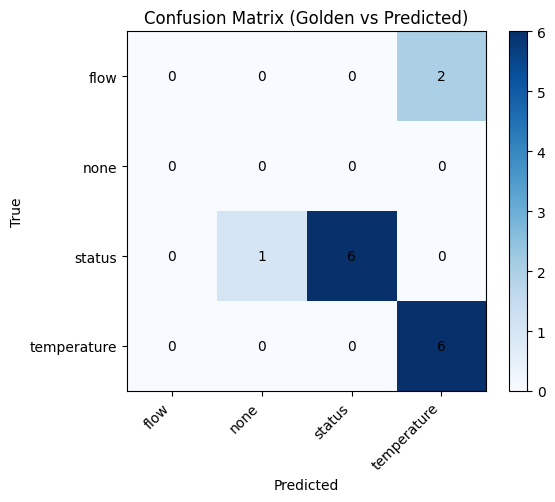

In [54]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)

def evaluate_with_golden_from_csv(csv_path):
    df = pd.read_csv(csv_path)

    if "Golden_Tag" not in df.columns:
        print("! There are no Golden_Tag column in CSV. Please add Golden_Tag.")
        return

    df_eval = df[
        df["Golden_Tag"].notna() &
        (df["Golden_Tag"].astype(str).str.strip() != "")
    ].copy()

    if len(df_eval) == 0:
        print("! There are no rows filled in Golden_Tag")
        return

    y_true = df_eval["Golden_Tag"].astype(str)
    y_pred = df_eval["Predicted_Tag"].astype(str)

    labels = sorted(set(y_true) | set(y_pred))

    print("\n* evaluate Golden label based performance:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"* Accuracy (Golden based): {acc:.3f}")

    # Macro F1
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"* Macro F1 (Golden based): {macro_f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(
        cm,
        index=[f"T:{l}" for l in labels],
        columns=[f"P:{l}" for l in labels]
    )
    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(cm_df.to_string())

    # Visualization
    try:
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(cm, cmap="Blues")
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)

        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, cm[i, j],
                        ha="center", va="center", color="black")

        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title("Confusion Matrix (Golden vs Predicted)")
        fig.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"(except matplotlib visualization: {e})")


# call
csv_path = OUTPUT_CSV_FILE  # same path
evaluate_with_golden_from_csv(csv_path)
